# Packing solver logos in CPMpy, with visualization

Given the logos of CPMpy and its solvers, pack them in a minimum 2D area around the CPMpy logo.

This example requires you to install _matplotlib_ and _Pillow_.


In [8]:
! pip install matplotlib Pillow --quiet


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

import cpmpy as cp
from cpmpy.expressions.utils import all_pairs


In [ ]:
# the CPMpy model and variables
def model_logo_packing(widths, heights, center_idx=0):
    n = len(widths)

    # max dimensions of the whole area
    area_max_x, area_max_y = sum(widths), sum(heights)

    # Decision variables
    pos_x = cp.intvar(0, area_max_x, shape=n)
    pos_y = cp.intvar(0, area_max_y, shape=n)

    total_x = cp.max([x + w for x, w in zip(pos_x, widths)])
    total_y = cp.max([y + h for y, h in zip(pos_y, heights)])

    m = cp.Model()

    # No-overlap: every logo fully above, below or next to every other logo
    for i, j in all_pairs(range(n)):
        m += ((pos_x[i] + widths[i] <= pos_x[j]) |
              (pos_x[j] + widths[j] <= pos_x[i]) |
              (pos_y[i] + heights[i] <= pos_y[j]) |
              (pos_y[j] + heights[j] <= pos_y[i]))

    # Keep the packing roughly square (avoid long strips)
    m += (total_x <= 2 * total_y)
    m += total_x <= total_y

    # Hard-center the CPMpy logo (allow 1 unit slack for odd sizes)
    m += cp.abs(2 * pos_x[center_idx] + widths[center_idx] - total_x) <= 1
    m += cp.abs(2 * pos_y[center_idx] + heights[center_idx] - total_y) <= 1

    # Minimize half-perimeter
    m.minimize(total_x + total_y)

    return m, (pos_x, pos_y, total_x, total_y)


In [11]:
# the visualisation: draw logos on a matplotlib figure
def visualize_logos(images, widths, heights, pos_x, pos_y, opaque_idx=0):
    total_x = max(x + w for x, w in zip(pos_x, widths))
    total_y = max(y + h for y, h in zip(pos_y, heights))

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlim(0, total_x)
    ax.set_ylim(total_y, 0)  # top-left origin, like image coordinates
    ax.set_aspect("equal")

    for i, (img, w, h, x, y) in enumerate(zip(images, widths, heights, pos_x, pos_y)):
        alpha = 1.0 if i == opaque_idx else 0.6  # CPMpy opaque, others a bit transparent
        ax.imshow(img, extent=(x, x + w, y + h, y), interpolation="bilinear", alpha=alpha)

    plt.title(f"Area: {total_x * total_y}  ({total_x} x {total_y})")
    ax.set_xticks([])
    ax.set_yticks([])
    return plt.show()


In [12]:
# Logos from examples/logos/; None means a text placeholder patch
LOGO_DIR = Path("logos")
if not LOGO_DIR.exists():
    LOGO_DIR = Path("examples/logos")  # when run from the repo root

LOGOS = [
    ("CPMpy", "cpmpy.png"),
    ("OR-Tools", "ortools.png"),
    ("Z3", "z3.png"),
    ("MiniZinc", "minizinc.png"),
    ("GCS", None),
    ("Gurobi", "gurobi.png"),
    ("PySAT", "pysat.png"),
    ("PySDD", None),
    ("Exact", None),
    ("Choco", "choco.png"),
    ("Pumpkin", "pumpkin.png"),
    ("IBM CPLEX / CPO", "ibm.png"),
    ("Pindakaas", "pindakaas.png"),
    ("HiGHS", "highs.png"),
    ("Hexaly", "hexaly.png"),
    ("RC2", None),
    ("SCIP", "scip.png"),
]

LOGO_SIZE = 100       # longer side for solver logos
CPMPY_SIZE = 150      # 1.5x bigger


def make_logo_patch(text, height=400):
    """Text placeholder when no official logo is available."""
    font = ImageFont.load_default(size=int(height * 0.72))
    bbox = ImageDraw.Draw(Image.new("RGB", (1, 1))).textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    pad_x, pad_y = int(height * 0.18), int(height * 0.12)
    size = (tw + 2 * pad_x, max(height, th + 2 * pad_y))

    img = Image.new("RGB", size, "white")
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 0, size[0] - 1, size[1] - 1], outline="black", width=2)
    draw.text((size[0] // 2, size[1] // 2), text, fill="black", anchor="mm", font=font)
    return img


names, images, widths, heights = [], [], [], []
for i, (name, filename) in enumerate(LOGOS):
    if filename is None:
        img = make_logo_patch(name)
    else:
        img = Image.open(LOGO_DIR / filename).convert("RGB")
    w0, h0 = img.size
    target = CPMPY_SIZE if i == 0 else LOGO_SIZE
    scale = target / max(w0, h0)
    w = max(2, int(round(w0 * scale / 2) * 2))
    h = max(2, int(round(h0 * scale / 2) * 2))
    names.append(name)
    images.append(img)
    widths.append(w)
    heights.append(h)

print(f"{len(names)} logos:")
for name, w, h in zip(names, widths, heights):
    print(f"  {name:16s}  {w:3d} x {h:3d}")


17 logos:
  CPMpy             134 x 150
  OR-Tools           94 x 100
  Z3                100 x  62
  MiniZinc          100 x 100
  GCS               100 x  56
  Gurobi            100 x  26
  PySAT             100 x 100
  PySDD             100 x  38
  Exact             100 x  48
  Choco             100 x  86
  Pumpkin           100 x  86
  IBM CPLEX / CPO   100 x  38
  Pindakaas         100 x  56
  HiGHS             100 x  22
  Hexaly            100 x  34
  RC2               100 x  58
  SCIP              100 x 100


In [13]:
# model, solve, visualize
(model, (pos_x, pos_y, total_x, total_y)) = model_logo_packing(widths, heights, center_idx=0)

sat = model.solve(time_limit=60)
if not sat:
    raise Exception("No solution found.")

# text output
print(f"Total area: {total_x.value() * total_y.value()}")
print("pos_x:", pos_x.value())
print("pos_y:", pos_y.value())

Total area: 129592
pos_x: [100  13 106   0 234 210 234   0   0 234 212 107 112 113 211 111   3]
pos_y: [119   2 325 188 246   0 146 102 140  60 302   1 269  97  26  39 288]


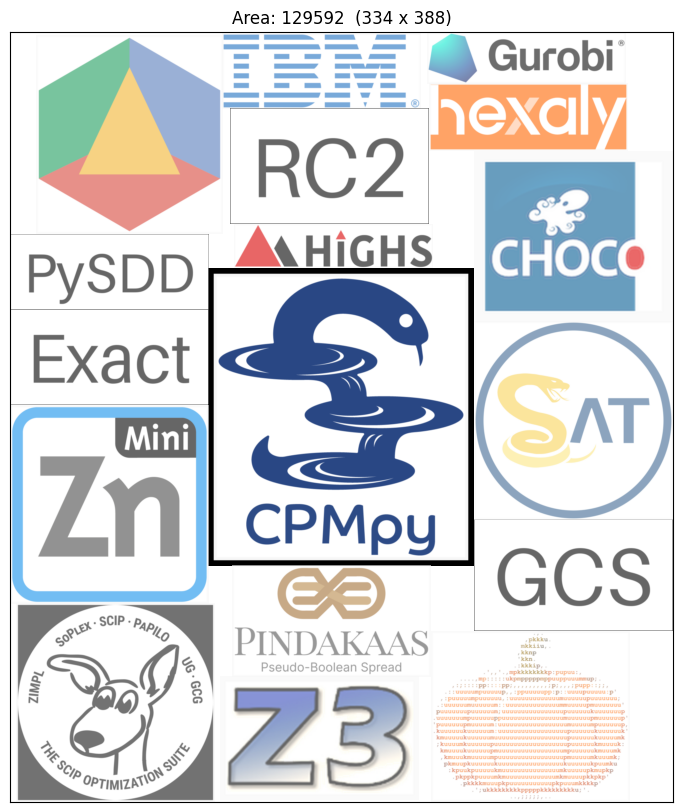

In [14]:
# visualization
visualize_logos(images, widths, heights, pos_x.value(), pos_y.value())